# TESS Exoplanet Pipeline — Step-by-Step Walkthrough

This notebook runs each pipeline stage in order using `TESSAnalysis`.

Install from the **project root** (`tess_exoplanet_pipeline/`, not `notebooks/`):

```bash
cd ../..   # or: cd ~/Desktop/Siya/exoplanet_modelling/tess_exoplanet_pipeline
pip install -e ".[inference,stellar]"
```

The `[inference]` extra installs `exoplanet`, `exoplanet-core`, `pymc`, `celerite2`, and `arviz`.

In [1]:
# !pip install -e ".[inference,stellar]"


In [15]:
%matplotlib inline

from tess_pipeline import TESSAnalysis

## Configuration

Create an analysis session. All options map to `PipelineConfig` fields.

In [17]:
# Option A: download from MAST (target required)
# analysis = TESSAnalysis(
#     "TIC 261136679",
#     inference=True,
#     search_method="tls",
#     sectors=1,
#     cadence=120,
#     chains=2,
#     draws=500,
#     tune=500,
    # chains=1,
    # draws=100,
    # tune=100,
#     plots=True,
#     verbose=True,
# )

# Option B: load local FITS (no target needed — TIC, RA, Dec from FITS headers)
FITS_PATH = "../data/fits/tess2018206045859-s0001-0000000261136679-0120-s_lc.fits"

analysis = TESSAnalysis(
    lightcurve_source="fits",
    lightcurve_fits=[FITS_PATH],
    inference=True,
    search_method="tls",
    plots=True,
    verbose=True,
    chains=1,
    draws=100,
    tune=100
)

## 1. Resolve target

In [18]:
analysis.resolve_target()
analysis.results.target

11:12:02  INFO      tess_pipeline.analysis.stages.target  Resolving target from local FITS inputs
11:12:02  INFO      tess_pipeline.data.metadata  Inferred TIC 270501383 from FITS header: ../data/fits/tess2018206045859-s0001-0000000261136679-0120-s_lc.fits
11:12:02  INFO      tess_pipeline.data.metadata  Inferred coordinates from FITS header: ../data/fits/tess2018206045859-s0001-0000000261136679-0120-s_lc.fits (RA=324.535016, Dec=-31.737484)
11:12:02  INFO      tess_pipeline.analysis.stages.target  Resolved to TIC 270501383


{'tic_id': 270501383,
 'name': 'TIC 270501383',
 'ra': 324.535016310363,
 'dec': -31.7374835163051}

## 2. Look up published period (NASA Exoplanet Archive)

In [20]:
analysis.lookup_archive_period()
analysis.results.period

11:12:14  INFO      tess_pipeline.analysis.stages.period  Querying NASA Exoplanet Archive for TIC 270501383
11:12:14  INFO      tess_pipeline.catalogs.nasa_archive  No local NASA archive entry found for TIC 270501383


{}

## 3. Load light curves

In [21]:
raw = analysis.load_lightcurves()

raw

11:12:15  INFO      tess_pipeline.analysis.stages.lightcurve  Loading TESS light curves from local FITS files
11:12:15  INFO      tess_pipeline.data.download  [fits] Step 1/4: normalizing FITS paths
11:12:15  INFO      tess_pipeline.data.download  [fits] Step 2/4: 1 FITS file(s) queued
11:12:15  INFO      tess_pipeline.data.download  [fits] Step 3/4: reading file 1/1: ../data/fits/tess2018206045859-s0001-0000000261136679-0120-s_lc.fits
11:12:15  INFO      tess_pipeline.data.download  [fits] Step 4/4: loaded 1 light curve(s) from local FITS in 0.2s


## 4. Preprocess

In [22]:
lc = analysis.preprocess()
lc

11:12:18  INFO      tess_pipeline.analysis.stages.lightcurve  Preprocessing light curves
11:12:18  DEBUG     tess_pipeline.data.preprocess  Stitched 1 sectors → 18171 cadences
11:12:19  INFO      tess_pipeline.data.preprocess  Preprocessing complete: 18171 cadences remain


## 5. Period search (TLS / BLS)

In [ ]:
detection = analysis.search_period()
detection

11:12:57  INFO      tess_pipeline.analysis.stages.period  No archive period; running TLS search
11:12:57  INFO      tess_pipeline.transit.detection  Running TLS (period 0.5–100.0 d)
11:12:57  DEBUG     tess_pipeline.transit.tls  TLS kwargs: {'period_min': 0.5, 'period_max': 100.0}
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 38 durations
Searching 18171 data points, 2540 periods from 0.601 to 13.878 days
Using all 8 CPU threads


 23%|██▎       | 594/2540 periods | 00:19<00:28

## 6. Stellar characterization

In [8]:
analysis.query_gaia()
analysis.characterize_star()
analysis.query_sdss()
analysis.results.stellar

00:24:21  INFO      tess_pipeline.analysis.stages.stellar  Querying Gaia DR3
Maintenance with possible short-time disconnections: 29 June 2026 18:00–20:00 CEST
INFO: Query finished. [astroquery.utils.tap.core]
00:24:31  WARNING   tess_pipeline.catalogs.gaia  Gaia DR3: r_star not available for this source
00:24:31  INFO      tess_pipeline.analysis.stages.stellar  Running stellar characterization (isoclassify)
00:24:31  WARNING   tess_pipeline.catalogs.stellar  Insufficient Gaia parameters for isoclassify (need r_star, teff, parallax)
00:24:31  WARNING   tess_pipeline.catalogs.stellar  isoclassify failed; falling back to Gaia-only parameters
00:24:31  WARNING   tess_pipeline.catalogs.stellar  Gaia R★ unavailable; stellar characterization incomplete
00:24:31  INFO      tess_pipeline.analysis.stages.stellar  Querying SDSS for radial velocity
00:24:31  INFO      tess_pipeline.catalogs.sdss  No SDSS spectroscopic match within 3 arcsec
00:24:31  INFO      tess_pipeline.analysis.stages.stellar

{'r_star': None,
 'r_star_err': None,
 'm_star': None,
 'm_star_err': None,
 'teff': 6116.94775390625,
 'teff_err': 6117.814453125,
 'logg': 4.153900146484375,
 'logg_err': None,
 'feh': -0.05299999937415123,
 'feh_err': None,
 'lum': None,
 'lum_err': None,
 'age': None,
 'age_err': None,
 'method': 'gaia_only',
 'rho_star': None,
 'rho_star_err': None}

## 7. Bayesian transit fit

In [23]:
analysis.fit_transit()
analysis.derive_planet_parameters()
analysis.check_convergence()
analysis.results.planet

RuntimeError: No period available; run lookup_archive() or search() first

## 8. Figures and export

11:00:31  INFO      tess_pipeline.analysis.stages.visualization  Generating diagnostic figures


ValueError: Keyword arguments ['kind', 'marginals', 'point_estimate'] have been passed as **kwargs but have no active aesthetic mapped to them. Keyword arguments must define values to use in their respective aesthetic mapping.

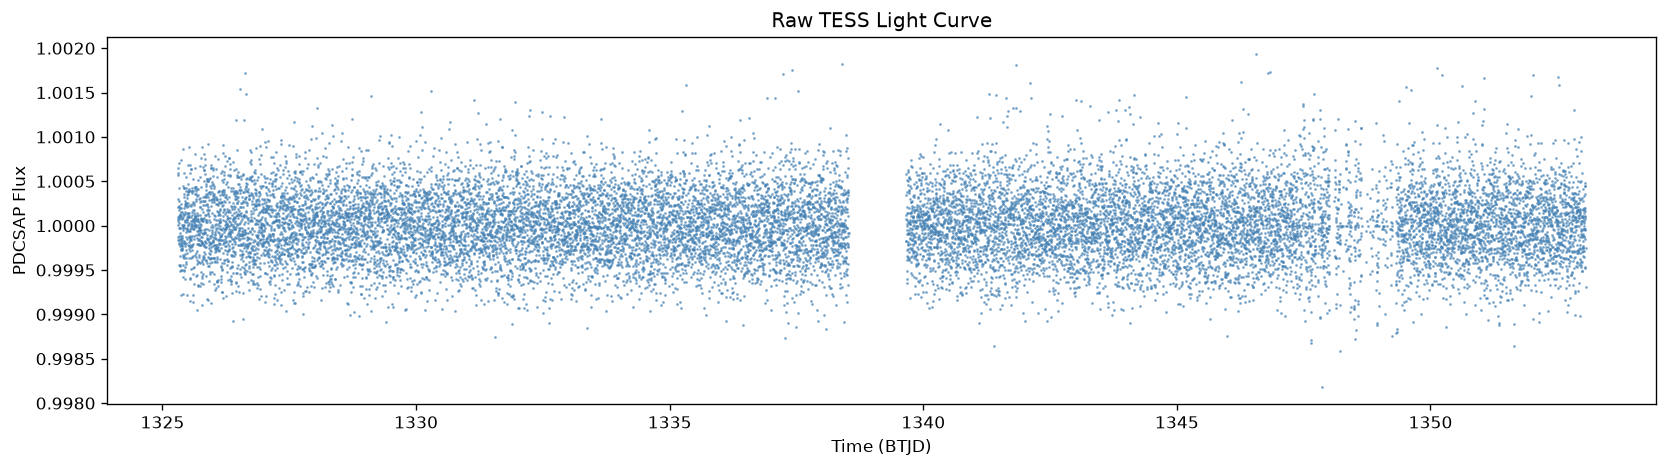

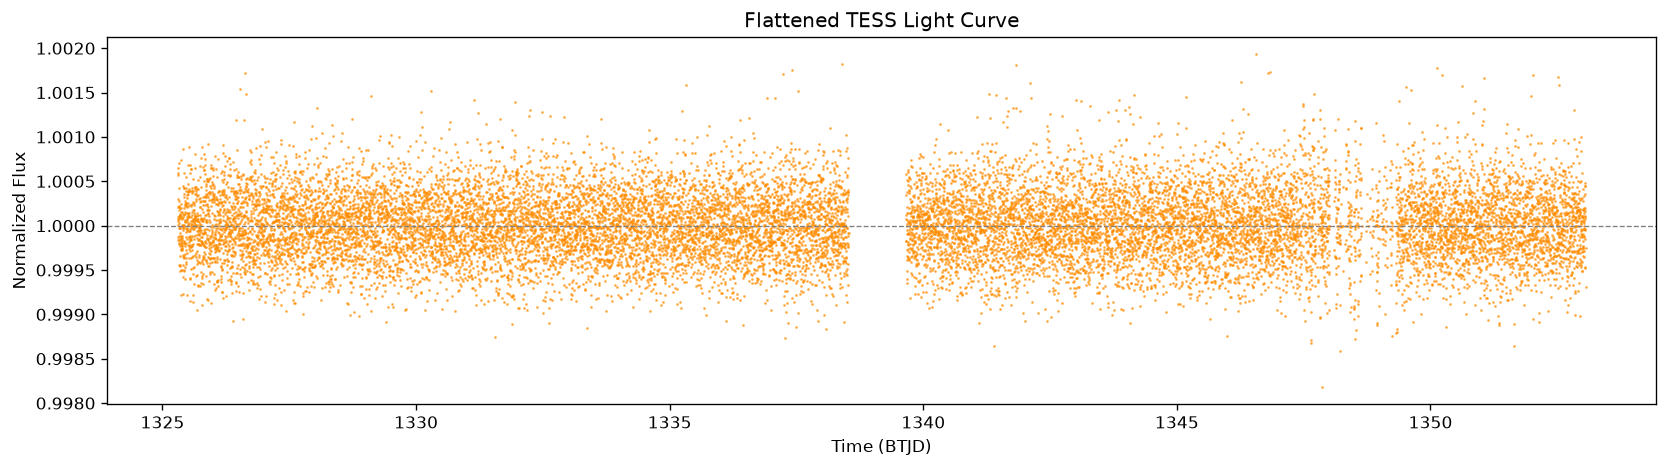

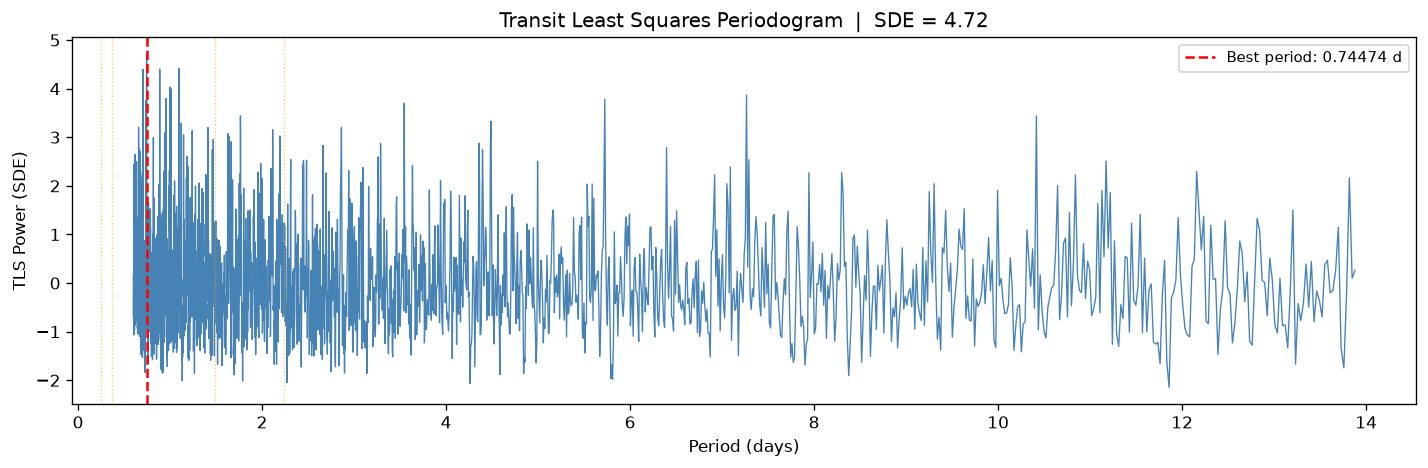

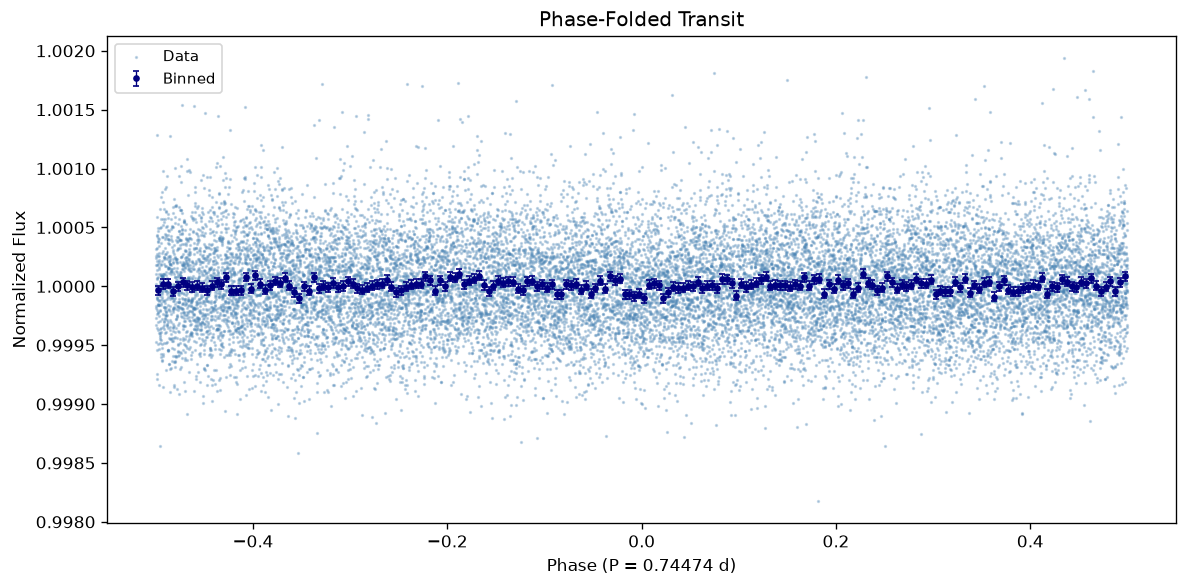

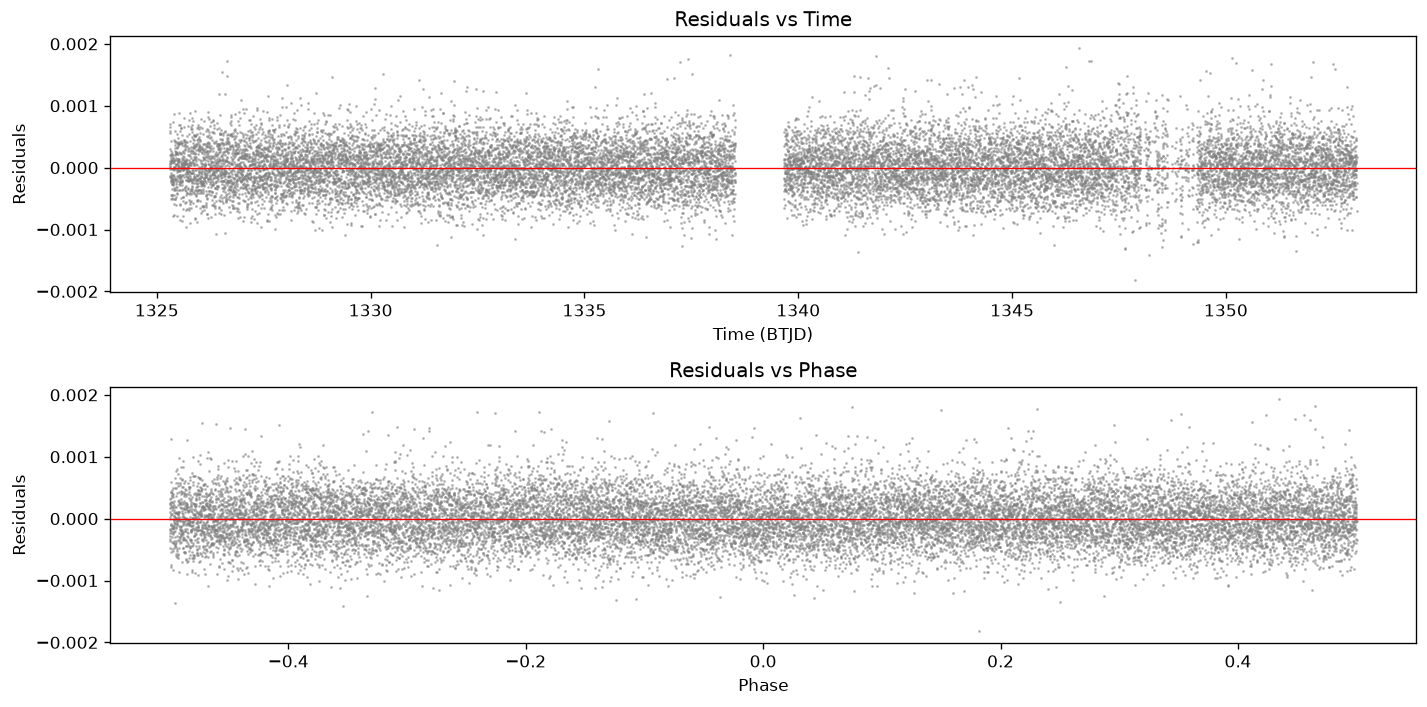

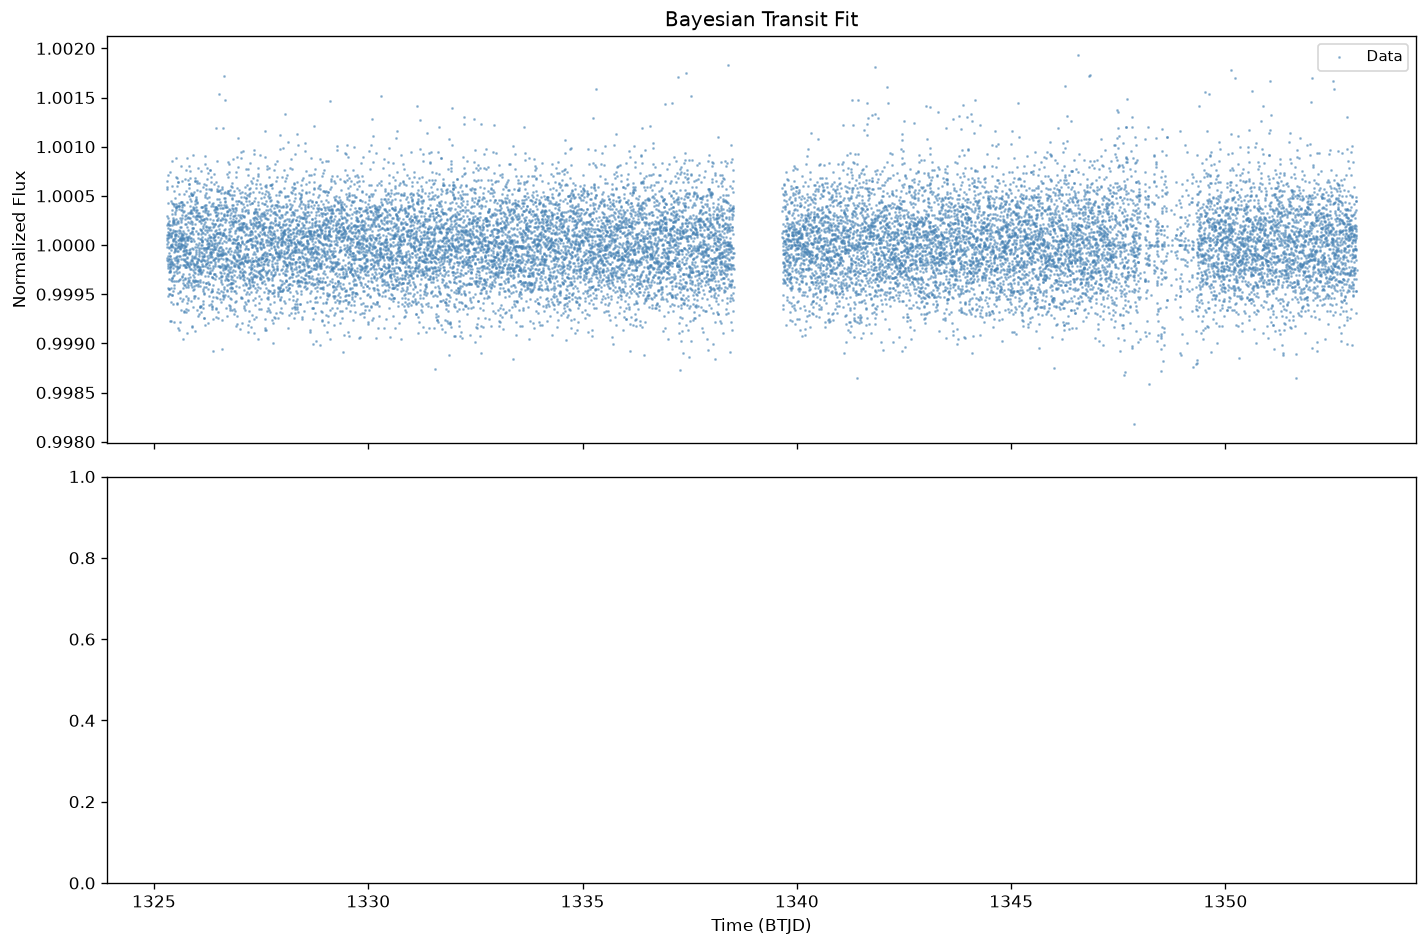

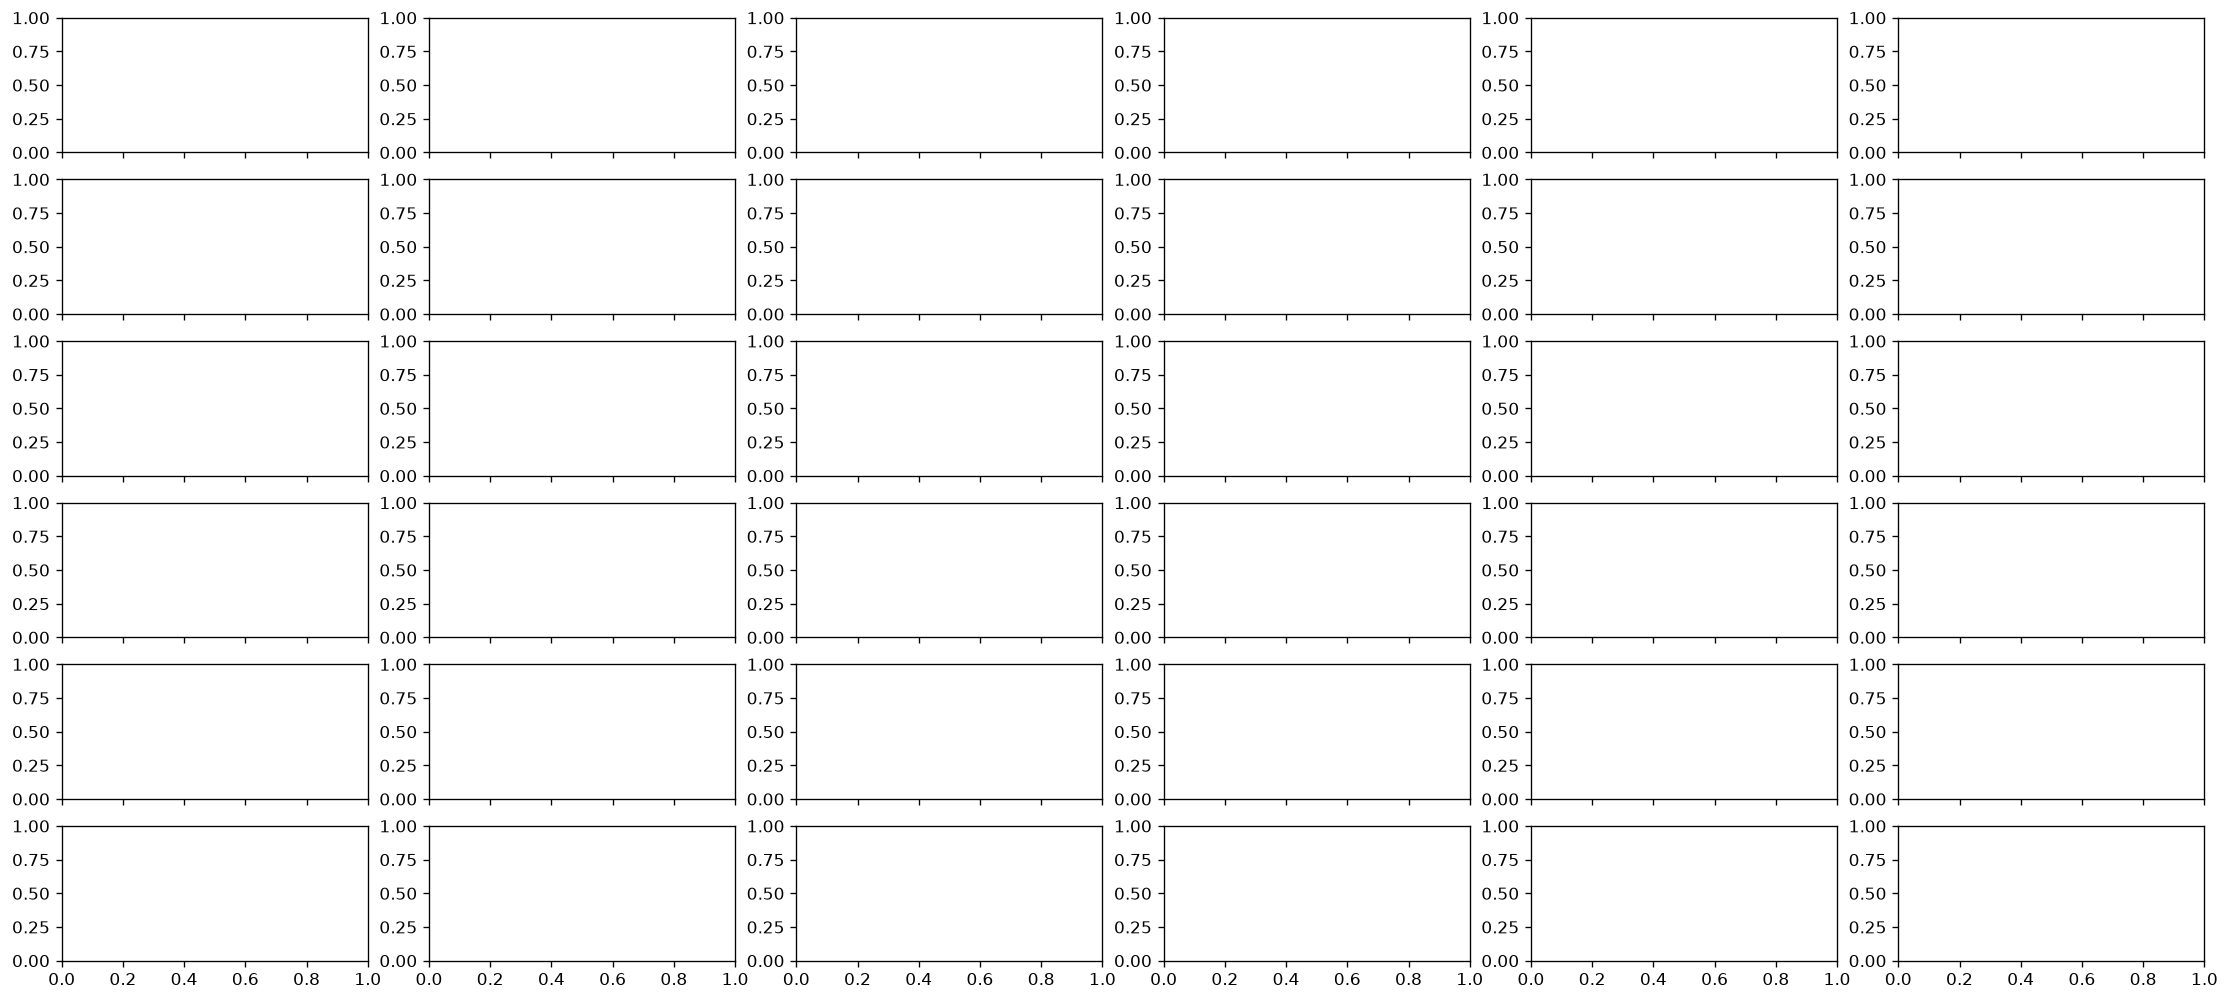

In [13]:
analysis.generate_figures()
analysis.results.summary()
analysis.results.plot_all()

In [14]:
# Optional: save all outputs to disk
analysis.save("output")

11:00:43  INFO      tess_pipeline.io.export  Saving results to output
11:00:43  DEBUG     tess_pipeline.io.export  Saved CSV: output/TIC270501383_summary.csv
11:00:43  DEBUG     tess_pipeline.io.export  Saved JSON: output/TIC270501383_metadata.json
11:00:43  WARNING   tess_pipeline.io.export  Could not save posterior: cannot write NetCDF files with format='NETCDF4' because none of the suitable backend libraries (netCDF4, h5netcdf) are installed
11:00:43  DEBUG     tess_pipeline.io.export  Saved light curve FITS: output/TIC270501383_lightcurve.fits
11:00:43  INFO      tess_pipeline.io.export  Export complete: output


## Alternative: run all stages at once

Equivalent to calling every step above in sequence:

In [ ]:
results = TESSAnalysis(TARGET, inference=True).run()
results.summary()